In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from config import DATA_RAW, DATA_PROCESSED

# Plot style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv(DATA_RAW / "cloud_metrics_historical.csv", parse_dates=["timestamp"])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (21600, 17)
Columns: ['timestamp', 'resource_id', 'resource_type', 'hour', 'day_of_week', 'is_weekend', 'is_month_end', 'cpu_utilization', 'memory_utilization', 'network_in_mbps', 'network_out_mbps', 'disk_io_mbps', 'request_count', 'error_rate_pct', 'cost_per_hour', 'is_anomaly', 'anomaly_type']


,timestamp,resource_id,resource_type,hour,day_of_week,is_weekend,is_month_end,cpu_utilization,memory_utilization,network_in_mbps,network_out_mbps,disk_io_mbps,request_count,error_rate_pct,cost_per_hour,is_anomaly,anomaly_type
0,2026-02-09 01:11:45.658706,ec2-ml-01,EC2-GPU,0,0,0,0,25.42,37.57,59.684524,2.900999,35.59,202,0.111,8.175265,1,network_burst
1,2026-02-09 02:11:45.658706,ec2-ml-01,EC2-GPU,1,0,0,0,43.17,35.23,8.900000,5.330000,12.20,168,0.408,3.480700,0,none
2,2026-02-09 03:11:45.658706,ec2-ml-01,EC2-GPU,2,0,0,0,30.65,40.36,42.010000,0.500000,28.20,264,0.131,4.101100,0,none
3,2026-02-09 04:11:45.658706,ec2-ml-01,EC2-GPU,3,0,0,0,29.55,38.62,70.310000,14.340000,29.67,379,1.440,3.811000,0,none
4,2026-02-09 05:11:45.658706,ec2-ml-01,EC2-GPU,4,0,0,0,26.75,30.14,0.500000,9.280000,35.32,33,0.675,3.716600,0,none


In [3]:
print("=== DTYPES ===")
print(df.dtypes)
print("\n=== NULL COUNTS ===")
print(df.isnull().sum())
print("\n=== BASIC STATS ===")
df.describe().round(2)

=== DTYPES ===
timestamp             datetime64[ns]
resource_id                   object
resource_type                 object
hour                           int64
day_of_week                    int64
is_weekend                     int64
is_month_end                   int64
cpu_utilization              float64
memory_utilization           float64
network_in_mbps              float64
network_out_mbps             float64
disk_io_mbps                 float64
request_count                  int64
error_rate_pct               float64
cost_per_hour                float64
is_anomaly                     int64
anomaly_type                  object
dtype: object

=== NULL COUNTS ===
timestamp             0
resource_id           0
resource_type         0
hour                  0
day_of_week           0
is_weekend            0
is_month_end          0
cpu_utilization       0
memory_utilization    0
network_in_mbps       0
network_out_mbps      0
disk_io_mbps          0
request_count         0
error_rat

,timestamp,hour,day_of_week,is_weekend,is_month_end,cpu_utilization,memory_utilization,network_in_mbps,network_out_mbps,disk_io_mbps,request_count,error_rate_pct,cost_per_hour,is_anomaly
count,21600,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00
mean,2026-03-26 00:41:45.658706432,11.50,2.97,0.28,0.09,23.59,43.64,44.11,26.45,32.73,405.39,0.51,2.32,0.07
min,2026-02-09 01:11:45.658706,0.00,0.00,0.00,0.00,0.51,1.00,0.50,0.50,0.50,0.00,0.00,0.08,0.00
25%,2026-03-03 12:56:45.658705920,5.75,1.00,0.00,0.00,8.74,21.19,24.41,14.34,19.55,252.00,0.15,0.74,0.00
50%,2026-03-26 00:41:45.658705920,11.50,3.00,0.00,0.00,18.26,36.03,40.52,24.43,32.23,397.00,0.35,1.46,0.00
75%,2026-04-17 12:26:45.658705920,17.25,5.00,1.00,0.00,32.53,66.75,57.73,34.82,45.42,561.00,0.70,2.98,0.00
max,2026-05-10 00:11:45.658706,23.00,6.00,1.00,1.00,100.00,100.00,670.18,412.77,94.18,1023.00,5.36,69.90,1.00
std,NaN,6.92,1.99,0.45,0.28,20.23,28.49,38.47,22.85,17.44,191.84,0.50,2.75,0.26


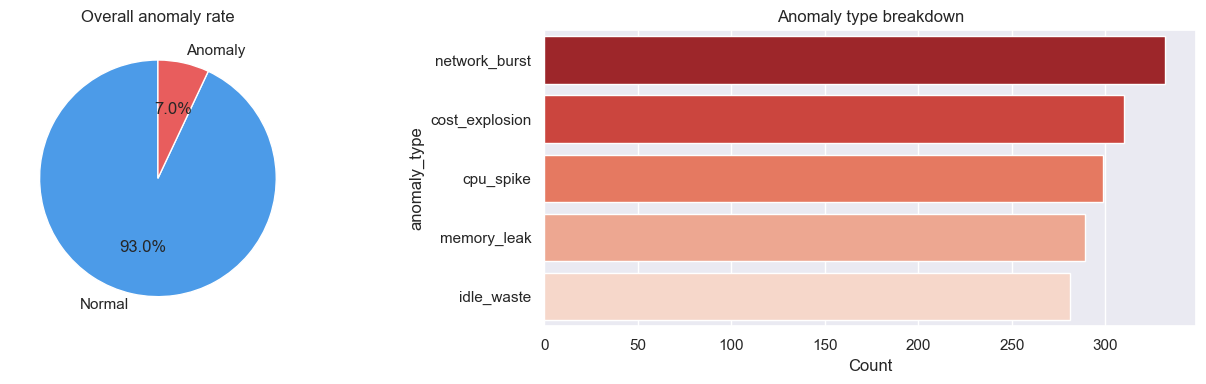


Total anomalies: 1,511 / 21,600 rows
Anomaly rate: 7.00%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall anomaly rate
counts = df['is_anomaly'].value_counts()
axes[0].pie(counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
            colors=['#4C9BE8', '#E85D5D'], startangle=90)
axes[0].set_title('Overall anomaly rate')

# Anomaly types
atype_counts = df[df['is_anomaly'] == 1]['anomaly_type'].value_counts()
sns.barplot(x=atype_counts.values, y=atype_counts.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Anomaly type breakdown')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"\nTotal anomalies: {df['is_anomaly'].sum():,} / {len(df):,} rows")
print(f"Anomaly rate: {df['is_anomaly'].mean():.2%}")

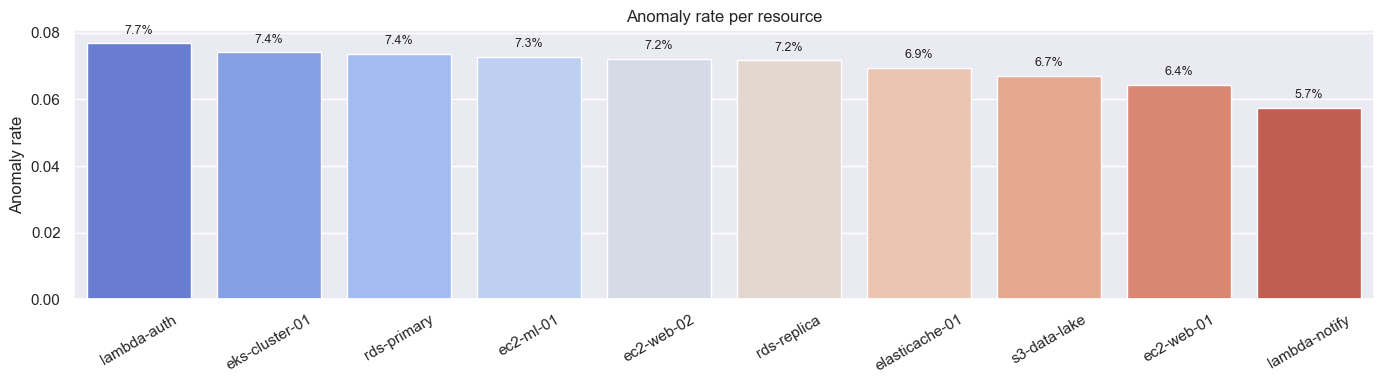

In [5]:
resource_anomaly = df.groupby('resource_id')['is_anomaly'].agg(['sum', 'mean']).reset_index()
resource_anomaly.columns = ['resource_id', 'anomaly_count', 'anomaly_rate']
resource_anomaly = resource_anomaly.sort_values('anomaly_rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
bars = sns.barplot(data=resource_anomaly, x='resource_id', y='anomaly_rate', palette='coolwarm', ax=ax)
ax.set_title('Anomaly rate per resource')
ax.set_ylabel('Anomaly rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for bar, rate in zip(ax.patches, resource_anomaly['anomaly_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

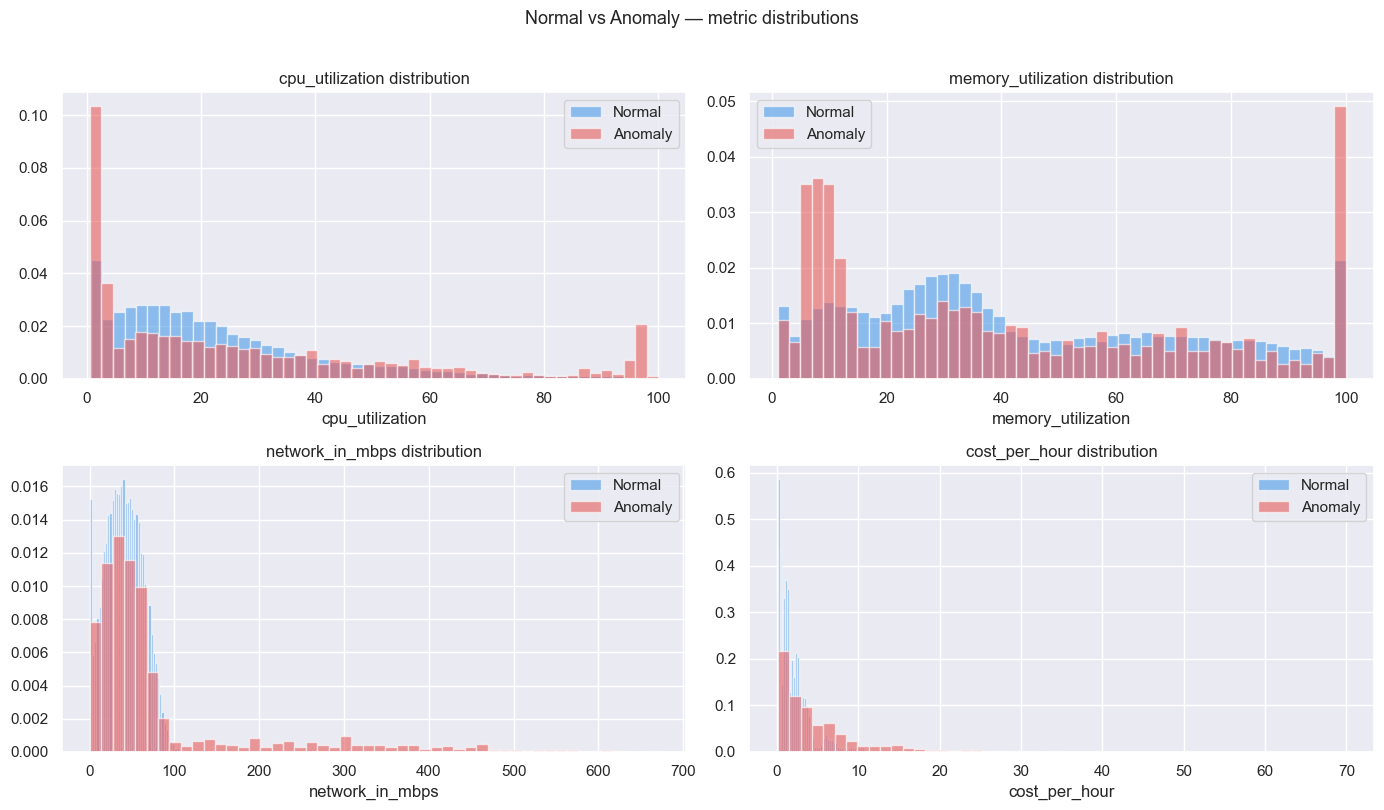

In [6]:
metrics = ['cpu_utilization', 'memory_utilization', 'network_in_mbps', 'cost_per_hour']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    normal  = df[df['is_anomaly'] == 0][metric]
    anomaly = df[df['is_anomaly'] == 1][metric]
    axes[i].hist(normal,  bins=50, alpha=0.6, color='#4C9BE8', label='Normal',  density=True)
    axes[i].hist(anomaly, bins=50, alpha=0.6, color='#E85D5D', label='Anomaly', density=True)
    axes[i].set_title(f'{metric} distribution')
    axes[i].legend()
    axes[i].set_xlabel(metric)

plt.suptitle('Normal vs Anomaly — metric distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

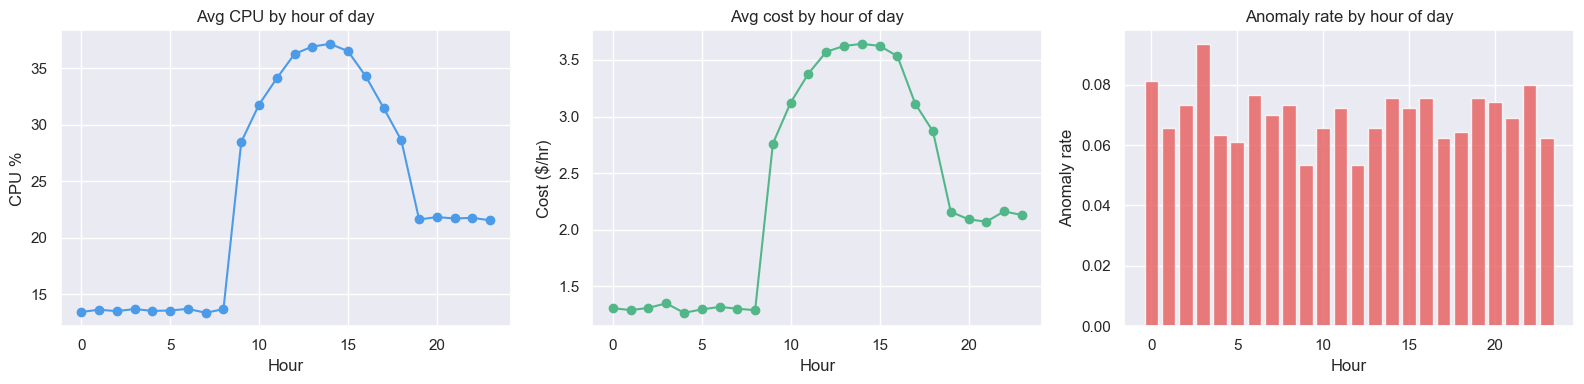

In [7]:
hourly = df.groupby('hour').agg(
    avg_cpu=('cpu_utilization', 'mean'),
    avg_cost=('cost_per_hour', 'mean'),
    anomaly_rate=('is_anomaly', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hourly['hour'], hourly['avg_cpu'], marker='o', color='#4C9BE8')
axes[0].set_title('Avg CPU by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('CPU %')

axes[1].plot(hourly['hour'], hourly['avg_cost'], marker='o', color='#52B788')
axes[1].set_title('Avg cost by hour of day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Cost ($/hr)')

axes[2].bar(hourly['hour'], hourly['anomaly_rate'], color='#E85D5D', alpha=0.8)
axes[2].set_title('Anomaly rate by hour of day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Anomaly rate')

plt.tight_layout()
plt.show()

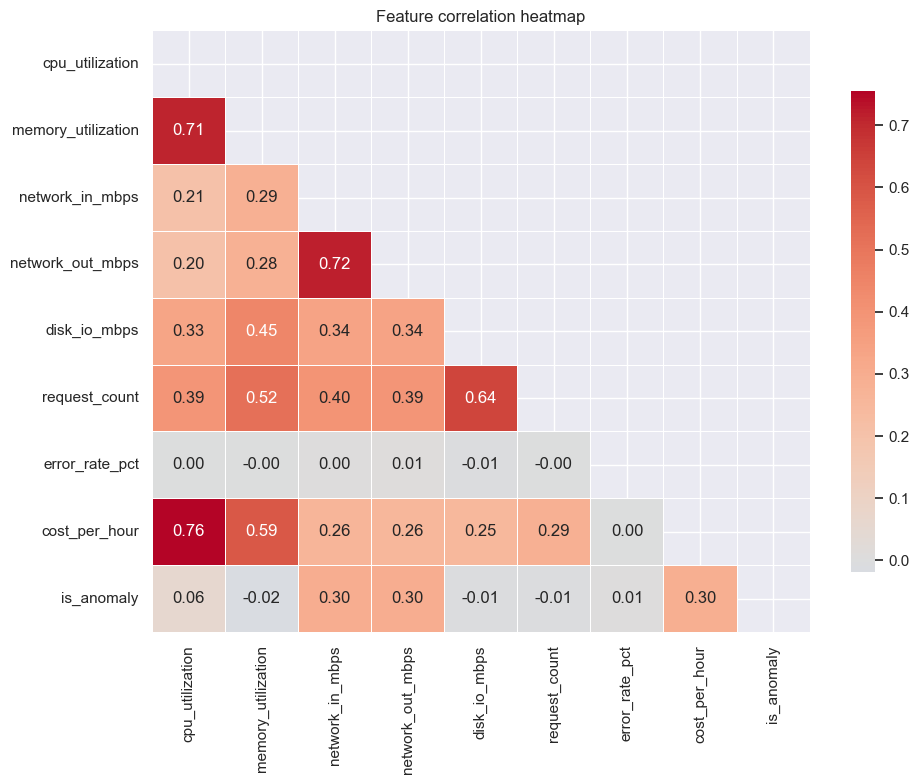

In [9]:
numeric_cols = ['cpu_utilization', 'memory_utilization', 'network_in_mbps',
                'network_out_mbps', 'disk_io_mbps', 'request_count',
                'error_rate_pct', 'cost_per_hour', 'is_anomaly']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation heatmap')
plt.tight_layout()
plt.show()

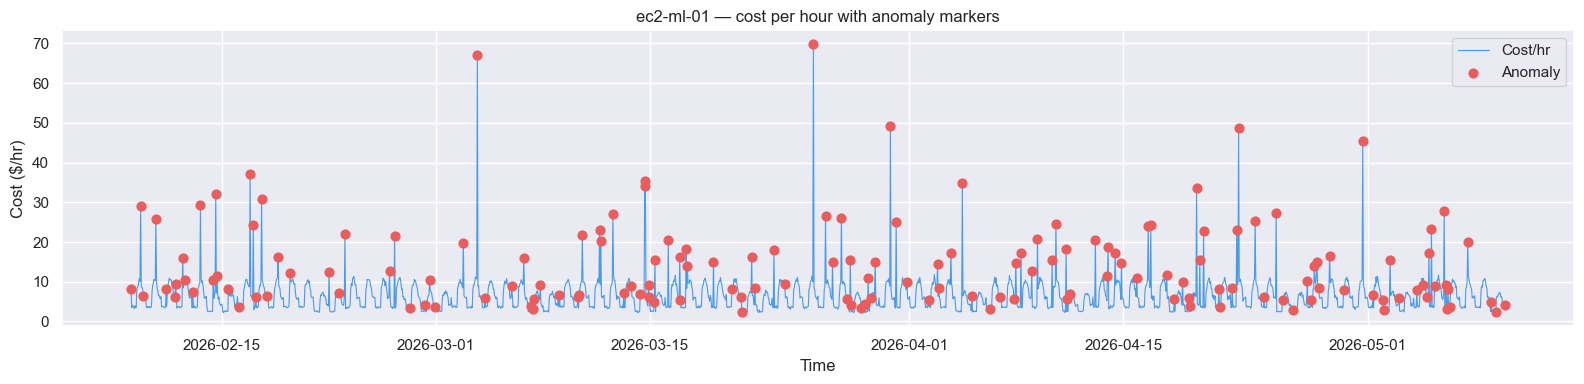

In [10]:
resource_df = df[df['resource_id'] == 'ec2-ml-01'].copy()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(resource_df['timestamp'], resource_df['cost_per_hour'],
        color='#4C9BE8', linewidth=0.8, label='Cost/hr')

anomalies = resource_df[resource_df['is_anomaly'] == 1]
ax.scatter(anomalies['timestamp'], anomalies['cost_per_hour'],
           color='#E85D5D', s=40, zorder=5, label='Anomaly')

ax.set_title('ec2-ml-01 — cost per hour with anomaly markers')
ax.set_xlabel('Time')
ax.set_ylabel('Cost ($/hr)')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total records       : {len(df):,}")
print(f"Resources           : {df['resource_id'].nunique()}")
print(f"Date range          : {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Anomaly rate        : {df['is_anomaly'].mean():.2%}")
print(f"Null values         : {df.isnull().sum().sum()}")
print(f"Numeric features    : {len(numeric_cols) - 1}")
print(f"\nHighest corr with is_anomaly:")
print(corr['is_anomaly'].drop('is_anomaly').abs().sort_values(ascending=False).round(3))

EDA SUMMARY
Total records       : 21,600
Resources           : 10
Date range          : 2026-02-09 to 2026-05-10
Anomaly rate        : 7.00%
Null values         : 0
Numeric features    : 8

Highest corr with is_anomaly:
network_out_mbps      0.300
network_in_mbps       0.299
cost_per_hour         0.296
cpu_utilization       0.060
memory_utilization    0.018
disk_io_mbps          0.008
error_rate_pct        0.007
request_count         0.005
Name: is_anomaly, dtype: float64
